In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [18]:
df=pd.read_excel(r"../data/Prozessdaten_PDCA_SixSigma_Orangensaft.xlsx")
df=df.rename(columns={
    df.columns[0]:"Durchlaufzeit"
})
df=df.drop(columns="Fehler")

In [19]:
df.head()

,Durchlaufzeit
0,16.785505
1,13.270233
2,16.193588
3,14.105569
4,21.432806


In [20]:
df["Durchschnitt"]=df["Durchlaufzeit"].median()
df["Abweichung"]=df["Durchlaufzeit"]-df["Durchschnitt"]
df["squared"]=df["Abweichung"].apply(lambda x: x**2)
df["summed/len"]=df["squared"].sum()/len(df)


In [21]:
df

,Durchlaufzeit,Durchschnitt,Abweichung,squared,summed/len
0,16.785505,14.941139,1.844366,3.401686,12.277826
1,13.270233,14.941139,-1.670906,2.791926,12.277826
2,16.193588,14.941139,1.252450,1.568630,12.277826
3,14.105569,14.941139,-0.835570,0.698177,12.277826
4,21.432806,14.941139,6.491668,42.141751,12.277826
...,...,...,...,...,...
995,17.716610,14.941139,2.775471,7.703242,12.277826
996,9.044885,14.941139,-5.896254,34.765807,12.277826
997,11.858689,14.941139,-3.082450,9.501498,12.277826
998,11.150240,14.941139,-3.790899,14.370913,12.277826


In [22]:
df

,Durchlaufzeit,Durchschnitt,Abweichung,squared,summed/len
0,16.785505,14.941139,1.844366,3.401686,12.277826
1,13.270233,14.941139,-1.670906,2.791926,12.277826
2,16.193588,14.941139,1.252450,1.568630,12.277826
3,14.105569,14.941139,-0.835570,0.698177,12.277826
4,21.432806,14.941139,6.491668,42.141751,12.277826
...,...,...,...,...,...
995,17.716610,14.941139,2.775471,7.703242,12.277826
996,9.044885,14.941139,-5.896254,34.765807,12.277826
997,11.858689,14.941139,-3.082450,9.501498,12.277826
998,11.150240,14.941139,-3.790899,14.370913,12.277826


In [23]:
mean = df["Durchschnitt"].iloc[0]
sigma = df["summed/len"].iloc[0]

df["Sigma"] = sigma

for i in range(1, 7):
    df[f"+{i}σ"] = mean + i * sigma
    df[f"-{i}σ"] = mean - i * sigma

df[["Durchlaufzeit", "Durchschnitt", "Sigma",
    "+1σ", "-1σ", "+2σ", "-2σ", "+3σ", "-3σ", "+6σ", "-6σ"]].head()

,Durchlaufzeit,Durchschnitt,Sigma,+1σ,-1σ,+2σ,-2σ,+3σ,-3σ,+6σ,-6σ
0,16.785505,14.941139,12.277826,27.218965,2.663313,39.496791,-9.614513,51.774616,-21.892339,88.608094,-58.725817
1,13.270233,14.941139,12.277826,27.218965,2.663313,39.496791,-9.614513,51.774616,-21.892339,88.608094,-58.725817
2,16.193588,14.941139,12.277826,27.218965,2.663313,39.496791,-9.614513,51.774616,-21.892339,88.608094,-58.725817
3,14.105569,14.941139,12.277826,27.218965,2.663313,39.496791,-9.614513,51.774616,-21.892339,88.608094,-58.725817
4,21.432806,14.941139,12.277826,27.218965,2.663313,39.496791,-9.614513,51.774616,-21.892339,88.608094,-58.725817


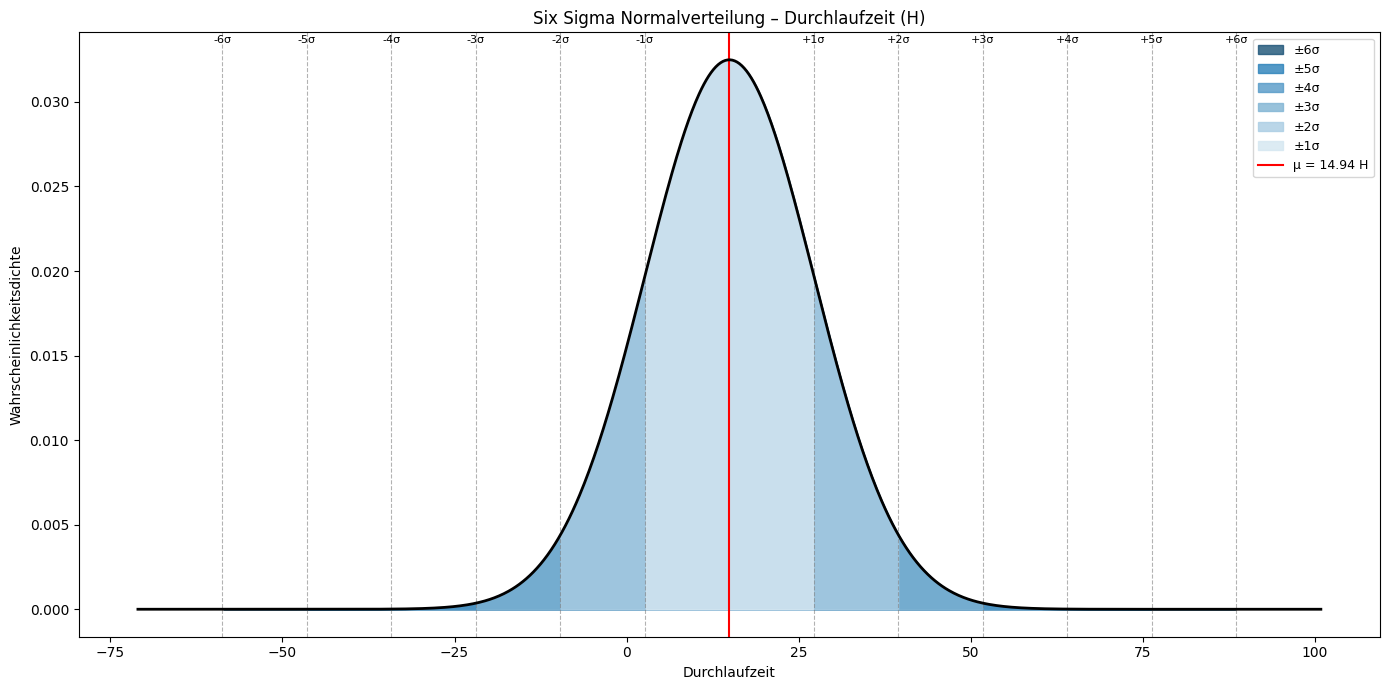

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

x = np.linspace(mean - 7 * sigma, mean + 7 * sigma, 1000)
y = stats.norm.pdf(x, mean, sigma)

colors = ["#d4e6f1", "#a9cce3", "#7fb3d3", "#5499c7", "#2980b9", "#1a5276"]
labels = [
    "±1σ", "±2σ", "±3σ",
    "±4σ", "±5σ", "±6σ",
]

for i in range(6, 0, -1):
    ax.fill_between(
        x, y,
        where=(x >= mean - i * sigma) & (x <= mean + i * sigma),
        color=colors[i - 1], alpha=0.8, label=labels[i - 1],
    )

for i in range(1, 7):
    for sign, pos in (("+", mean + i * sigma), ("-", mean - i * sigma)):
        ax.axvline(pos, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.text(pos, max(y) * 1.03, f"{sign}{i}σ", ha="center", fontsize=8)

ax.axvline(mean, color="red", linewidth=1.5, label=f"μ = {mean:.2f} H")
ax.plot(x, y, "k-", linewidth=2)

ax.set_xlabel("Durchlaufzeit")
ax.set_ylabel("Wahrscheinlichkeitsdichte")
ax.set_title("Six Sigma Verteilung)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()